In [1]:
# IT22259752 - Logistic Regression & Preprocessing Lead
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


In [2]:
# Dataset loading
df = pd.read_csv('../data/StudentPerformanceFactors.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Shape: (6607, 20)
Rows: 6607, Columns: 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Target Distribution:
Performance
Medium    4573
High      1083
Low        951
Name: count, dtype: int64


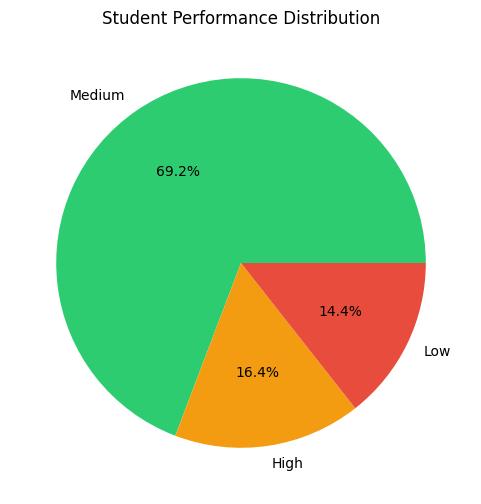

In [3]:
# Target variable - High / Medium / Low
bins = [0, 63, 70, 101]
labels = ['Low', 'Medium', 'High']
df['Performance'] = pd.cut(df['Exam_Score'], bins=bins, labels=labels)

print('Target Distribution:')
print(df['Performance'].value_counts())

# Pie chart
plt.figure(figsize=(6,6))
df['Performance'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#2ecc71','#f39c12','#e74c3c']
)
plt.title('Student Performance Distribution')
plt.ylabel('')
plt.show()

In [4]:
# Missing values check
print('Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Mode fill
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

print('✅ Missing values filled!')
print('Remaining:', df.isnull().sum().sum())

Missing Values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64
✅ Missing values filled!
Remaining: 235
